In [13]:
import json
import copy
import tldextract
import os

from collections import Counter
from agent_helper import ask_agent


In [14]:
from json_repair import repair_json


class Company:
    def __init__(
            self, name, domain, sector, market_value, 
            security_analysts, financial_assets, 
            domain_popularity, osint_domains
        ):
        self.name = name
        self.domain = domain
        self.sector = sector
        self.market_value = market_value
        self.security_analysts = security_analysts
        self.financial_assets = financial_assets
        self.domain_popularity = domain_popularity
        self.osint_domains = osint_domains
        self.registered_defensive_domains = []

class CompanyLoader:
    def __init__(self, infile: str, zonefile: str = None):
        self.companies = {}
        with open(infile, 'rt') as fin:
            for line in fin:
                data = json.loads(line)
                self.companies[data['domain']] = Company(
                    name = data['company'],
                    domain = data['domain'],
                    sector = data['naics_sector'],
                    market_value = data['market_value'],
                    security_analysts = data['security_analysts_est'],
                    financial_assets = data['assets'],
                    domain_popularity = data['popularity'],
                    osint_domains = data['osint_domains']
                )
        # check if extracted_defensive_domains.txt exists
        if os.path.exists('extracted_defensive_domains.txt'):
            with open('extracted_defensive_domains.txt', 'rt') as fin:
                for line in fin:
                    data = json.loads(line)
                    self.companies[data['domain']].registered_defensive_domains.extend(data['defensive_domains'])
            return
        with open(zonefile, 'rt') as fzone:
            # patch one prompt per 2000 lines
            while line := fzone.readline():
                count = 0
                patch = []
                while line and count < 3000:
                    patch.append(line.split(" ")[0].strip() + ' ')
                    count += 1
                    line = fzone.readline()
                count = 0
                prompt = f"""
                Given the following registered domain names:\n {''.join(patch)}\n\nFor each of the following company domains: {', '.join(self.companies.keys())}, identify any registered defensive domains that are similar to the company domain. Notice that not all the registered defensive domains are for the above companies. Format your response like:
                <damain1>: <defensive_domain1>, <defensive_domain2>, ...
                <domain2>: <defensive_domain1>, <defensive_domain2>, ...
                don't put any thing if there is no defensive domain found.
                \n\n
                """


                res_dict = ask_agent(prompt)
                # print(res_dict)
                for company_domain, defensive_domains in res_dict.items():
                    if company_domain in self.companies:
                        self.companies[company_domain].registered_defensive_domains.extend(defensive_domains)
        
                
    def get(self, name) -> Company:
        return self.companies.get(name)

In [15]:
class BrandProtector:
    def __init__(self, zone_infile: str, companies_infile: str, disputes_infile: str = None):
        # set the cost of the various actions
        self.dispute_cost = 1200
        self.registration_cost = 200
        self.budget = 100000

        self.qwerty = {
            '1': '2q', '2': '3wq1', '3': '4ew2', '4': '5re3', '5': '6tr4', '6': '7yt5', '7': '8uy6', '8': '9iu7', '9': '0oi8', '0': 'po9',
            'q': '12wa', 'w': '3esaq2', 'e': '4rdsw3', 'r': '5tfde4', 't': '6ygfr5', 'y': '7uhgt6', 'u': '8ijhy7', 'i': '9okju8', 'o': '0plki9', 'p': 'lo0',
            'a': 'qwsz', 's': 'edxzaw', 'd': 'rfcxse', 'f': 'tgvcdr', 'g': 'yhbvft', 'h': 'ujnbgy', 'j': 'ikmnhu', 'k': 'olmji', 'l': 'kop',
            'z': 'asx', 'x': 'zsdc', 'c': 'xdfv', 'v': 'cfgb', 'b': 'vghn', 'n': 'bhjm', 'm': 'njk', '-': '0p'
            }

        with open(zone_infile, 'rt') as fin:
            self.registered_domains = {parts[0][:-1] for line in fin if (parts := line.split())}
        self.company_loader = CompanyLoader(companies_infile, zone_infile)

        if disputes_infile:
            with open(disputes_infile, 'rt') as fin:
                self.disputes = json.load(fin)
        else:
            self.disputes = {}

    def generate(self, domain: str):
        # verify it is a valid domain
        extract_result = tldextract.extract(domain.lower())
        e2ld = extract_result.domain
        tld = extract_result.suffix

        domains = set()
        if e2ld and tld:
            # the five models of Wang et al., “Strider typo-patrol: Discovery and analysis of systematic typo-squatting,” 2nd Workshop on Steps to Reducing Unwanted Traffic on the Internet, 2006
            ## missing dot
            domains.add(f'www{e2ld}.{tld}')
            # character insertion and replacement
            for idx, orig in enumerate(e2ld):
                # insert before the character
                domains.update([f'{e2ld[:idx]}{ins}{e2ld[idx:]}.{tld}' for ins in self.qwerty[orig] + orig])
                # insert after the character
                domains.update([f'{e2ld[:idx + 1]}{ins}{e2ld[idx + 1:]}.{tld}' for ins in self.qwerty[orig] + orig])
                
                # replace the character
                domains.update([f'{e2ld[:idx]}{repl}{e2ld[idx + 1:]}.{tld}' for repl in self.qwerty[orig] + orig])
            
            # character transposition
            domains.update([
                f"{e2ld[:l]}{e2ld[r]}{e2ld[l]}{e2ld[r+1:]}.{tld}" 
                for l, r in zip(
                    range(len(e2ld)), range(1, len(e2ld))
                ) if e2ld[r] != e2ld[l]
            ])
        # registered domains are not considered
        return domains.difference(self.registered_domains)


    #TODO: Implement the function `predict`
    def predict(self, outfile: str):
        # get company's details
        candidates = set()
        for base_domain, company_details in self.company_loader.companies.items():
            # generate the transformations
            candidates.update([(base_domain, transformation) for transformation in self.generate(base_domain)])


        #TODO: Implement a technique to determine which domains should be registered (pairs of company domain and transformation)

        # this simple approach takes the first "n" candidates
        n = 100000 // 200
        to_register = list(candidates)[:n]
        
        
        # write to the output file
        with open(outfile, 'wt') as fout:
            fout.write('\n'.join([f'{base}:{mod}' for base, mod in to_register]))
    
    # **DO NOT MODIFY**
    def score(self, infile: str):
        if self.disputes:
            disputes = copy.deepcopy(self.disputes)
            profits = self.budget
            correct_guesses = Counter()
            missed_guesses = Counter()

            registrations = 0

            with open(infile, 'r') as submission_file:
                while profits:
                    line = submission_file.readline()
                    if line.strip():
                        root, domain = line.strip().split(':')
                        profits -= self.registration_cost

                        if root in disputes and domain in disputes[root]:
                            correct_guesses.update([disputes[root].pop(domain)])

                        registrations += 1
                    elif not submission_file.read():
                        break

            # estimate the penalties
            penalties = 0
            for root, entries in disputes.items():
                missed_guesses.update(entries.values())

                for _, risk_level in entries.items():
                    penalties += risk_level * 0.25 * self.dispute_cost
            profits -= penalties

            return {
                'domains_registered': registrations,
                'disputes_avoided': {
                    'low-risk': correct_guesses[1],
                    'medium-risk': correct_guesses[2],
                    'high-risk': correct_guesses[3]
                },
                'disputes_encountered': {
                    'low-risk': missed_guesses[1],
                    'medium-risk': missed_guesses[2],
                    'high-risk': missed_guesses[3]
                },
                'registration_cost': registrations * self.registration_cost,
                'penalties': penalties,
                'profits': max(0, profits)
            }
        else:
            print('Disputes data not available. Performance cannot be evaluated.')

In [16]:
zonefile = 'zonefile.txt'
# for the training data
companies_infile = 'companies-training.jsonl'
disputes_infile = 'disputes-training.json'
obp = BrandProtector(zonefile, companies_infile, disputes_infile)
# or this for the validation data (used on the leaderboard)
# companies_infile = 'companies-validation.jsonl'
# obp = BrandProtector(zonefile, companies_infile)

# # run the prediction code and save it to submission.txt
# obp.predict('submission.txt')

# # get the evaluation scores
# obp.score('submission.txt')

In [17]:
with open("extracted_defensive_domains.txt", 'wt') as fout:
    for company in obp.company_loader.companies.values():
        fout.write(f"{company.domain}: {company.registered_defensive_domains}\n")

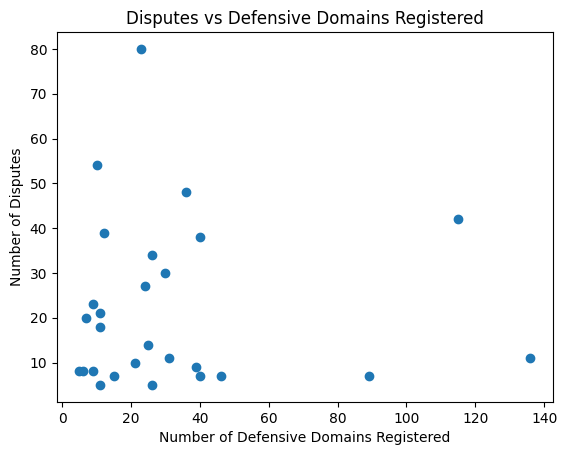

Correlation coefficient (#Defenses, #Disputes): -0.00730591583726827


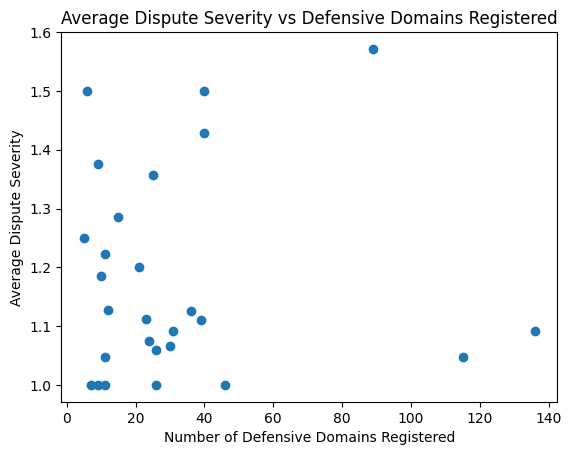

Correlation coefficient (#Defenses, Avg Severity): 0.029107851085994212


In [18]:
# scatter plot: number of disputes vs number of defensive domains registered

import matplotlib.pyplot as plt
import numpy as np

x = []
y = []
disputes_dict = {}
with open("disputes-training.json", 'rt') as fin:
    disputes_data = json.load(fin)
    for company_domain, disputes in disputes_data.items():
        disputes_dict[company_domain] = disputes
# print(disputes_dict)
for company in obp.company_loader.companies.values():
    num_defensive_domains = len(company.registered_defensive_domains)
    num_disputes = len(disputes_dict[company.domain])
    x.append(num_defensive_domains)
    y.append(num_disputes)
plt.scatter(x, y)
plt.xlabel('Number of Defensive Domains Registered')
plt.ylabel('Number of Disputes')
plt.title('Disputes vs Defensive Domains Registered')
plt.show()

corr = np.corrcoef(x, y)[0, 1]
print(f"Correlation coefficient (#Defenses, #Disputes): {corr}")

# # scatter plot: average dispute severity vs number of defensive domains registered
x = []
y = []
for domain, disputes in disputes_dict.items():
    num_defensive_domains = len(obp.company_loader.get(domain).registered_defensive_domains)
    x.append(num_defensive_domains)
    if disputes:
        avg_severity = sum(disputes.values()) / len(disputes)
    else:
        avg_severity = 0
    y.append(avg_severity)

plt.scatter(x, y)
plt.xlabel('Number of Defensive Domains Registered')
plt.ylabel('Average Dispute Severity')
plt.title('Average Dispute Severity vs Defensive Domains Registered')
plt.show()

corr = np.corrcoef(x, y)[0, 1]
print(f"Correlation coefficient (#Defenses, Avg Severity): {corr}")

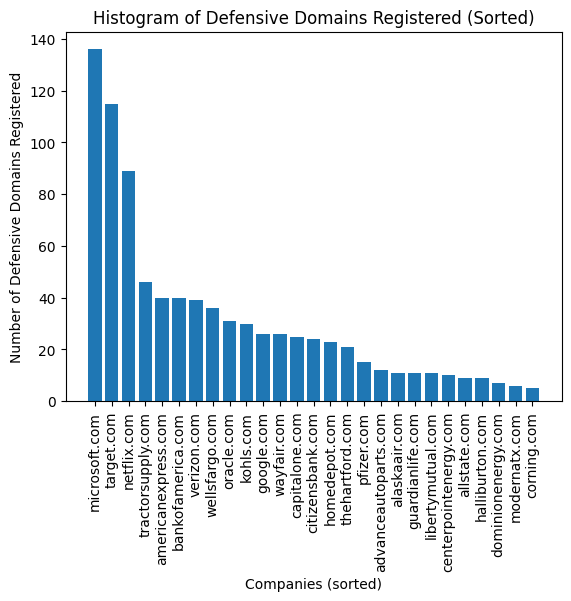

In [19]:
# sort companies by number of defensive domains registered
sorted_companies = sorted(
    obp.company_loader.companies.values(), 
    key=lambda c: len(c.registered_defensive_domains), 
    reverse=True
)
# plot histogram of number of defensive domains registered sorted by companies, show company domain on x-axis
num_defensive_domains = [len(c.registered_defensive_domains) for c in sorted_companies]
plt.bar([c.domain for c in sorted_companies], num_defensive_domains)
plt.xlabel('Companies (sorted)')
plt.ylabel('Number of Defensive Domains Registered')
plt.title('Histogram of Defensive Domains Registered (Sorted)')
plt.xticks(rotation=90)
plt.show()

In [20]:
# find all disputed domains that are registered as defensive domains
disputed_and_defensive = {}
for company_domain, disputes in disputes_dict.items():
    company = obp.company_loader.get(company_domain)
    if company:
        defensive_set = set(company.registered_defensive_domains)
        disputed_set = set(disputes.keys())
        common = defensive_set.intersection(disputed_set)
        if common:
            disputed_and_defensive[company_domain] = list((x, disputes[x]) for x in common)
            
print("Disputed domains that are also registered as defensive domains:")
for company_domain, common_domains in disputed_and_defensive.items():
    print(f"{company_domain}: {common_domains}")

Disputed domains that are also registered as defensive domains:
allstate.com: [('allsate.com', 1)]
oracle.com: [('oracel.com', 1)]
alaskaair.com: [('alaskaiar.com', 1)]
wellsfargo.com: [('welsfargo.com', 1), ('ellsfargo.com', 1)]
verizon.com: [('verzion.com', 1)]
bankofamerica.com: [('bankofamerca.com', 1), ('bnkofamerica.com', 1)]
capitalone.com: [('capital0ne.com', 2)]
target.com: [('tagret.com', 1), ('targdt.com', 1)]
halliburton.com: [('halliburtom.com', 2)]
google.com: [('oogle.com', 1), ('googl.com', 1)]
homedepot.com: [('homdepot.com', 2), ('homedepo.com', 1), ('omedepot.com', 1)]
kohls.com: [('kohlse.com', 1), ('kohld.com', 1)]
netflix.com: [('netflx.com', 1)]
